In [96]:
# Etapa 1 — Importando as bibliotecas necessárias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Bibliotecas carregadas com sucesso!")

✅ Bibliotecas carregadas com sucesso!


In [97]:
# Etapa 2 — Carregando o dataset

df = pd.read_excel("PCOS_data_without_infertility.xlsx", sheet_name=1)

print("✅ Dataset carregado com sucesso!")
print("Shape:", df.shape)

✅ Dataset carregado com sucesso!
Shape: (541, 45)


In [98]:
# Etapa 3 — Inspecionando os dados

df.head()


,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [99]:
# Verificando informações gerais do dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    int64  
 15  

In [100]:
# Verificando valores ausentes em cada coluna

df.isnull().sum()

Sl. No                      0
Patient File No.            0
PCOS (Y/N)                  0
 Age (yrs)                  0
Weight (Kg)                 0
Height(Cm)                  0
BMI                         0
Blood Group                 0
Pulse rate(bpm)             0
RR (breaths/min)            0
Hb(g/dl)                    0
Cycle(R/I)                  0
Cycle length(days)          0
Marraige Status (Yrs)       1
Pregnant(Y/N)               0
No. of aborptions           0
  I   beta-HCG(mIU/mL)      0
II    beta-HCG(mIU/mL)      0
FSH(mIU/mL)                 0
LH(mIU/mL)                  0
FSH/LH                      0
Hip(inch)                   0
Waist(inch)                 0
Waist:Hip Ratio             0
TSH (mIU/L)                 0
AMH(ng/mL)                  0
PRL(ng/mL)                  0
Vit D3 (ng/mL)              0
PRG(ng/mL)                  0
RBS(mg/dl)                  0
Weight gain(Y/N)            0
hair growth(Y/N)            0
Skin darkening (Y/N)        0
Hair loss(

In [101]:
# Etapa 4 — Limpeza dos dados

# Preenchendo o valor vazio com a média da coluna
media = df['Marraige Status (Yrs)'].mean()
df['Marraige Status (Yrs)'] = df['Marraige Status (Yrs)'].fillna(media)

# Verificando se ainda tem valores vazios
print("Valores vazios após limpeza:")
print(df.isnull().sum().sum())

Valores vazios após limpeza:
540


In [102]:
# Descobrindo qual coluna ainda tem valor vazio
print(df.isnull().sum()[df.isnull().sum() > 0])

Fast food (Y/N)      1
Unnamed: 44        539
dtype: int64


In [103]:
# Preenchendo o valor vazio de Fast food com a moda
moda = df['Fast food (Y/N)'].mode()[0]
df['Fast food (Y/N)'] = df['Fast food (Y/N)'].fillna(moda)

# Confirmando que não há mais valores vazios
print("Valores vazios após limpeza final:")
print(df.isnull().sum().sum())

Valores vazios após limpeza final:
539


In [104]:
print("Moda do Fast food (Y/N):", moda)
print("\nContagem de cada valor:")
print(df['Fast food (Y/N)'].value_counts())

Moda do Fast food (Y/N): 1.0

Contagem de cada valor:
Fast food (Y/N)
1.0    279
0.0    262
Name: count, dtype: int64


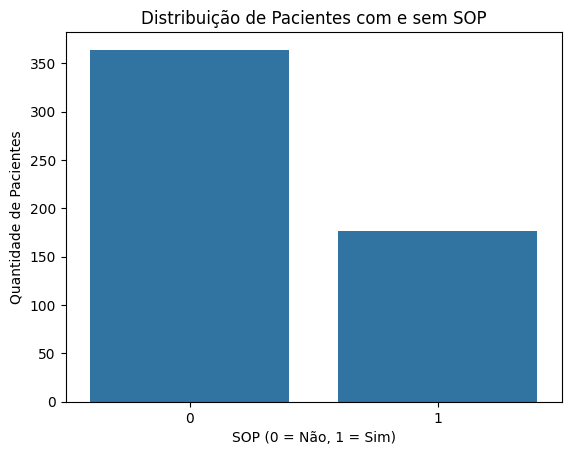

In [105]:
# Etapa 5 — Análise Exploratória
# Gráfico 1: Distribuição de pacientes com e sem SOP

sns.countplot(x='PCOS (Y/N)', data=df)
plt.title('Distribuição de Pacientes com e sem SOP')
plt.xlabel('SOP (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Pacientes')
plt.show()

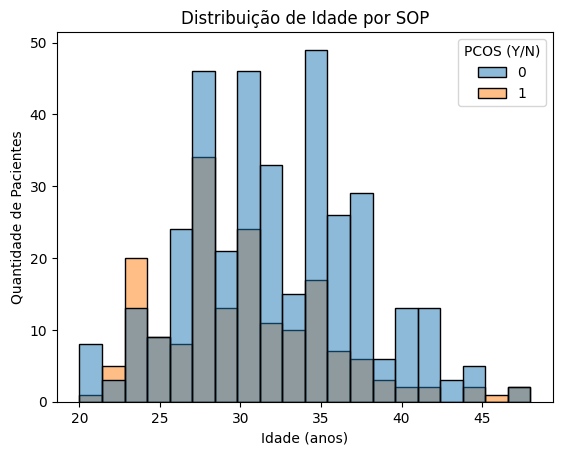

In [106]:
# Gráfico 2: Distribuição de idade das pacientes

sns.histplot(data=df, x=' Age (yrs)', hue='PCOS (Y/N)', bins=20)
plt.title('Distribuição de Idade por SOP')
plt.xlabel('Idade (anos)')
plt.ylabel('Quantidade de Pacientes')
plt.show()

In [107]:
# Verificando o nome exato das colunas
print(df.columns.tolist())

['Sl. No', 'Patient File No.', 'PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI', 'Blood Group', 'Pulse rate(bpm) ', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', '  I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)', 'Unnamed: 44']


In [108]:
# Limpando espaços extras nos nomes das colunas
df.columns = df.columns.str.strip()

# Confirmando
print(df.columns.tolist())

['Sl. No', 'Patient File No.', 'PCOS (Y/N)', 'Age (yrs)', 'Weight (Kg)', 'Height(Cm)', 'BMI', 'Blood Group', 'Pulse rate(bpm)', 'RR (breaths/min)', 'Hb(g/dl)', 'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)', 'Pregnant(Y/N)', 'No. of aborptions', 'I   beta-HCG(mIU/mL)', 'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH', 'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)', 'Unnamed: 44']


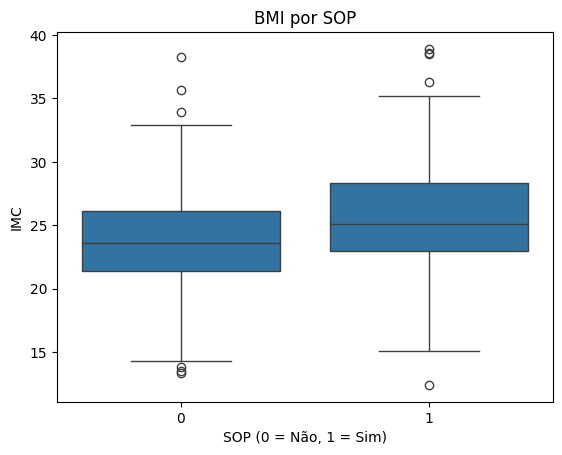

In [109]:
# Gráfico 3: BMI por SOP

sns.boxplot(x='PCOS (Y/N)', y='BMI', data=df)
plt.title('BMI por SOP')
plt.xlabel('SOP (0 = Não, 1 = Sim)')
plt.ylabel('IMC')
plt.show()

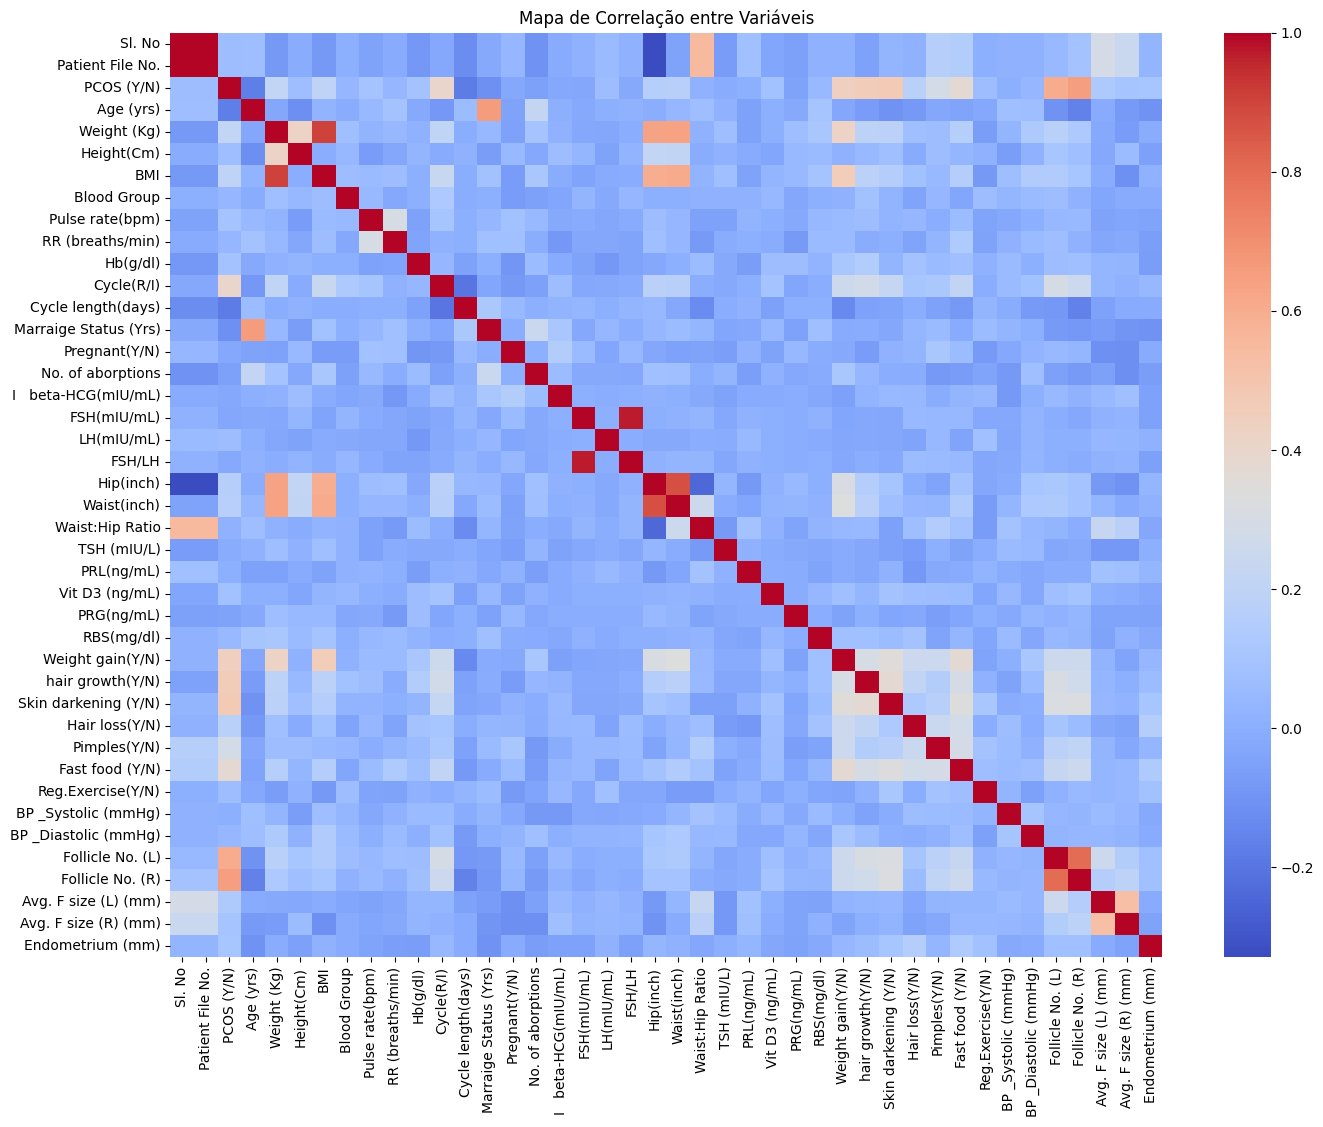

In [110]:
# Gráfico 4: Mapa de correlação entre variáveis numéricas

plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm')
plt.title('Mapa de Correlação entre Variáveis')
plt.show()

In [111]:
# Etapa 6 — Pré-processamento

# Removendo colunas de identificação que não ajudam o modelo
df = df.drop(columns=['Sl. No', 'Patient File No.'])

# Separando X (entradas) e y (alvo)
X = df.drop(columns=['PCOS (Y/N)'])
y = df['PCOS (Y/N)']

print("✅ X shape:", X.shape)
print("✅ y shape:", y.shape)

✅ X shape: (541, 42)
✅ y shape: (541,)


In [112]:
# Separando treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Treino:", X_train.shape)
print("✅ Teste:", X_test.shape)

✅ Treino: (432, 42)
✅ Teste: (109, 42)


In [113]:
# Verificando colunas com texto
print(X.dtypes[X.dtypes == 'object'])

II    beta-HCG(mIU/mL)    object
AMH(ng/mL)                object
Unnamed: 44               object
dtype: object


In [114]:
# Convertendo colunas de texto para número
X = X.copy()
X['II  beta-HCG(mIU/mL)'] = pd.to_numeric(X['II  beta-HCG(mIU/mL)'], errors='coerce')
X['AMH(ng/mL)'] = pd.to_numeric(X['AMH(ng/mL)'], errors='coerce')

# Preenchendo possíveis vazios gerados pela conversão com a média
X['II  beta-HCG(mIU/mL)'] = X['II  beta-HCG(mIU/mL)'].fillna(X['II  beta-HCG(mIU/mL)'].mean())
X['AMH(ng/mL)'] = X['AMH(ng/mL)'].fillna(X['AMH(ng/mL)'].mean())

# Confirmando que não há mais colunas de texto
print("Colunas object restantes:", X.dtypes[X.dtypes == 'object'].count())
print("✅ Pronto!")

KeyError: 'II  beta-HCG(mIU/mL)'

In [121]:
# Verificando nome exato das colunas object
for col in X.columns:
    if X[col].dtype == 'object':
        print(repr(col))

'Unnamed: 44'


In [115]:
# Convertendo colunas de texto para número
X = X.copy()
X['II    beta-HCG(mIU/mL)'] = pd.to_numeric(X['II    beta-HCG(mIU/mL)'], errors='coerce')
X['AMH(ng/mL)'] = pd.to_numeric(X['AMH(ng/mL)'], errors='coerce')

# Preenchendo possíveis vazios gerados pela conversão com a média
X['II    beta-HCG(mIU/mL)'] = X['II    beta-HCG(mIU/mL)'].fillna(X['II    beta-HCG(mIU/mL)'].mean())
X['AMH(ng/mL)'] = X['AMH(ng/mL)'].fillna(X['AMH(ng/mL)'].mean())

# Confirmando que não há mais colunas de texto
print("Colunas object restantes:", X.dtypes[X.dtypes == 'object'].count())
print("✅ Pronto!")

Colunas object restantes: 1
✅ Pronto!


In [122]:
# Re-separando treino e teste com X atualizado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("✅ Treino:", X_train.shape)
print("✅ Teste:", X_test.shape)

✅ Treino: (432, 42)
✅ Teste: (109, 42)


In [120]:
# Etapa 7 — Treinando os modelos
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Modelo 1: Árvore de Decisão
modelo_arvore = DecisionTreeClassifier(random_state=42)
modelo_arvore.fit(X_train, y_train)
print("✅ Árvore de Decisão treinada!")

# Modelo 2: Random Forest
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)
print("✅ Random Forest treinada!")

ValueError: could not convert string to float: '1.99.'

In [119]:
# Etapa 8 — Avaliando os modelos
from sklearn.metrics import classification_report, confusion_matrix

# Fazendo previsões
y_pred_arvore = modelo_arvore.predict(X_test)
y_pred_rf = modelo_rf.predict(X_test)

# Avaliando Árvore de Decisão
print("🌳 ÁRVORE DE DECISÃO:")
print(classification_report(y_test, y_pred_arvore))

# Avaliando Random Forest
print("🌲 RANDOM FOREST:")
print(classification_report(y_test, y_pred_rf))

AttributeError: 'DecisionTreeClassifier' object has no attribute 'tree_'

NameError: name 'y_pred_arvore' is not defined

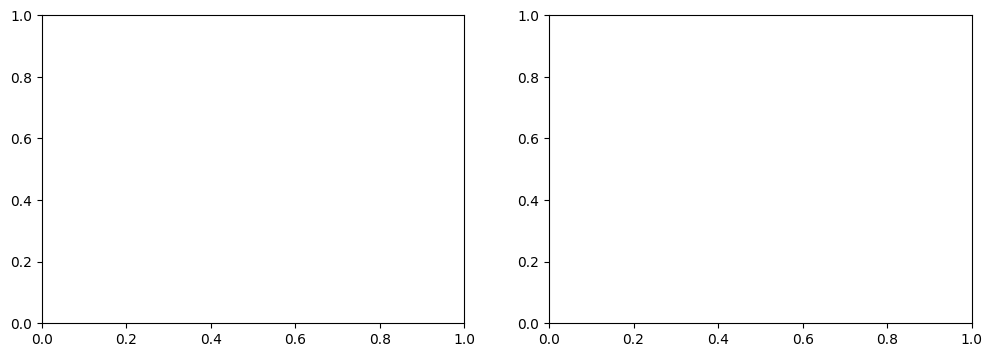

In [ ]:
# Etapa 9 — Matriz de Confusão
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Árvore de Decisão
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_arvore,
    display_labels=['Sem SOP', 'Com SOP'],
    ax=axes[0], colorbar=False
)
axes[0].set_title('Árvore de Decisão')

# Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Sem SOP', 'Com SOP'],
    ax=axes[1], colorbar=False
)
axes[1].set_title('Random Forest')

plt.suptitle('Matrizes de Confusão', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Etapa 10 — Feature Importance (Random Forest)
import pandas as pd
import matplotlib.pyplot as plt

# Pegando a importância de cada variável
importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

# Mostrando as 15 mais importantes
plt.figure(figsize=(10, 6))
importancias.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Variáveis Mais Importantes — Random Forest')
plt.ylabel('Importância')
plt.xlabel('Variável')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

NameError: name 'modelo_rf' is not defined

In [ ]:
# Etapa 10 — Feature Importance (Random Forest)

# Pegando os nomes das colunas que o modelo usou
nomes_colunas = X_train.columns

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=nomes_colunas
).sort_values(ascending=False)

# Mostrando as 15 mais importantes
plt.figure(figsize=(10, 6))
importancias.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Variáveis Mais Importantes — Random Forest')
plt.ylabel('Importância')
plt.xlabel('Variável')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ValueError: Length of values (41) does not match length of index (42)

In [ ]:
# Etapa 10 — Feature Importance (Random Forest)

# Pegando os nomes das colunas que o modelo usou
nomes_colunas = X_train.columns

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=nomes_colunas
).sort_values(ascending=False)

# Mostrando as 15 mais importantes
plt.figure(figsize=(10, 6))
importancias.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Variáveis Mais Importantes — Random Forest')
plt.ylabel('Importância')
plt.xlabel('Variável')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

ValueError: Length of values (41) does not match length of index (42)

In [ ]:
print("Colunas do modelo:", len(modelo_rf.feature_importances_))
print("Colunas do X_train:", len(X_train.columns))
print("Colunas do X:", len(X.columns))

Colunas do modelo: 41
Colunas do X_train: 42
Colunas do X: 42


In [ ]:
# Investigando a diferença de colunas
print("🔢 Quantidade no modelo:", len(modelo_rf.feature_importances_))
print("🔢 Quantidade no X_train:", len(X_train.columns))
print("🔢 Quantidade no X:", len(X.columns))

print("\n📋 Lista de colunas atuais no X:")
print(X.columns.tolist())

NameError: name 'modelo_rf' is not defined

In [ ]:
# Verificando se ainda existem valores nulos ou textos no treino
print("❌ Valores nulos no X_train:", X_train.isnull().sum().sum())
print("📋 Tipos de dados no X_train:", X_train.dtypes.unique())

❌ Valores nulos no X_train: 430
📋 Tipos de dados no X_train: [dtype('int64') dtype('float64') dtype('O')]


In [ ]:
# 1. Limpeza total no DataFrame principal (df) antes de qualquer separação
# Preenchendo nulos numéricos com a média e categóricos com a moda
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# 2. Garantir que as colunas problemáticas de ontem sejam convertidas
# Usamos 'coerce' para transformar qualquer erro de texto em nulo e depois limpamos
df['II    beta-HCG(mIU/mL)'] = pd.to_numeric(df['II    beta-HCG(mIU/mL)'], errors='coerce').fillna(0)
df['AMH(ng/mL)'] = pd.to_numeric(df['AMH(ng/mL)'], errors='coerce').fillna(0)

# 3. Separar X e y novamente agora com os dados limpos
X = df.drop(columns=['PCOS (Y/N)', 'Sl. No', 'Patient File No.', 'Unnamed: 44'], errors='ignore')
y = df['PCOS (Y/N)']

# 4. Refazer o train_test_split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("✅ Dados limpos e separados novamente!")
print("❌ Nulos no X_train:", X_train.isnull().sum().sum())

✅ Dados limpos e separados novamente!
❌ Nulos no X_train: 0


In [118]:
# Etapa 11 — Fazendo previsões e avaliando
# Aqui o modelo tenta adivinhar os resultados do grupo de teste
y_pred_arvore = modelo_arvore.predict(X_test)
y_pred_rf = modelo_rf.predict(X_test)

from sklearn.metrics import classification_report

print("📊 Avaliação da Árvore de Decisão:")
print(classification_report(y_test, y_pred_arvore))

print("\n🌲 Avaliação do Random Forest:")
print(classification_report(y_test, y_pred_rf))

AttributeError: 'DecisionTreeClassifier' object has no attribute 'tree_'

In [123]:
print("Colunas do modelo:", len(modelo_rf.feature_importances_))
print("Colunas do X_train:", len(X_train.columns))
print("Colunas do X:", len(X.columns))

Colunas do modelo: 41
Colunas do X_train: 42
Colunas do X: 42


In [124]:
# Retreinando os modelos com o X correto
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Modelo 1: Árvore de Decisão
modelo_arvore = DecisionTreeClassifier(random_state=42)
modelo_arvore.fit(X_train, y_train)

# Modelo 2: Random Forest
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

# Novas previsões
y_pred_arvore = modelo_arvore.predict(X_test)
y_pred_rf = modelo_rf.predict(X_test)

print("✅ Modelos retreinados corretamente!")
print("Colunas do modelo:", len(modelo_rf.feature_importances_))
print("Colunas do X_train:", len(X_train.columns))

ValueError: could not convert string to float: '.'

In [125]:
# Verificando se ainda há colunas com texto
for col in X.columns:
    if X[col].dtype == 'object':
        print(repr(col))
        print(X[col].unique())

'Unnamed: 44'
[nan '.' 7]


In [126]:
# Removendo a coluna inútil do X
X = X.drop(columns=['Unnamed: 44'])

# Confirmando
print("Colunas restantes:", X.shape)
print("Colunas object:", X.dtypes[X.dtypes == 'object'].count())
print("✅ X limpo!")

Colunas restantes: (541, 41)
Colunas object: 0
✅ X limpo!


In [127]:
# Retreinando os modelos com o X correto
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Modelo 1: Árvore de Decisão
modelo_arvore = DecisionTreeClassifier(random_state=42)
modelo_arvore.fit(X_train, y_train)

# Modelo 2: Random Forest
modelo_rf = RandomForestClassifier(random_state=42)
modelo_rf.fit(X_train, y_train)

# Novas previsões
y_pred_arvore = modelo_arvore.predict(X_test)
y_pred_rf = modelo_rf.predict(X_test)

print("✅ Modelos retreinados corretamente!")
print("Colunas do modelo:", len(modelo_rf.feature_importances_))
print("Colunas do X_train:", len(X_train.columns))

✅ Modelos retreinados corretamente!
Colunas do modelo: 41
Colunas do X_train: 41


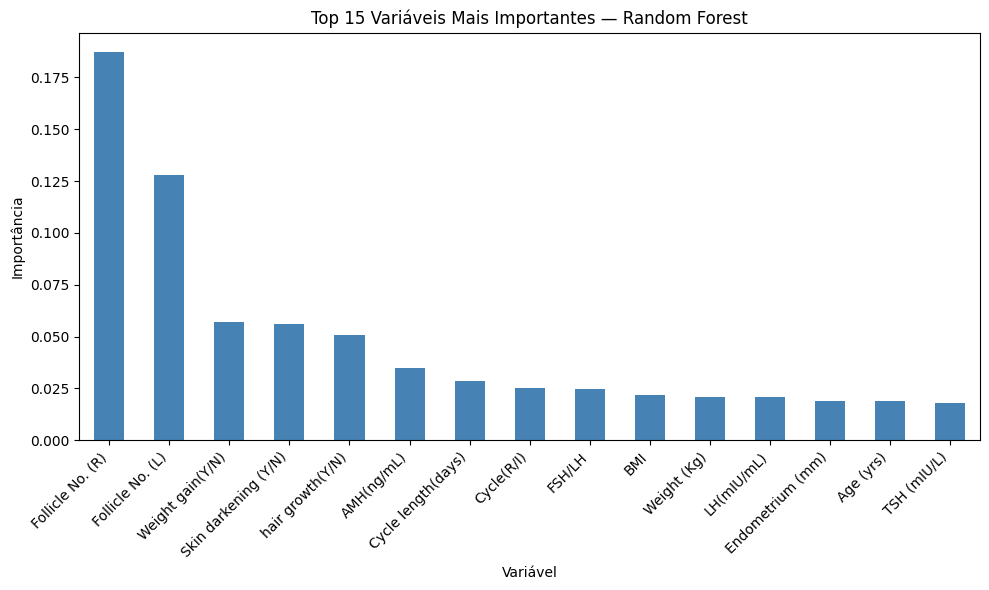

In [128]:
# Etapa 10 — Feature Importance (Random Forest)

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Mostrando as 15 mais importantes
plt.figure(figsize=(10, 6))
importancias.head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Variáveis Mais Importantes — Random Forest')
plt.ylabel('Importância')
plt.xlabel('Variável')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

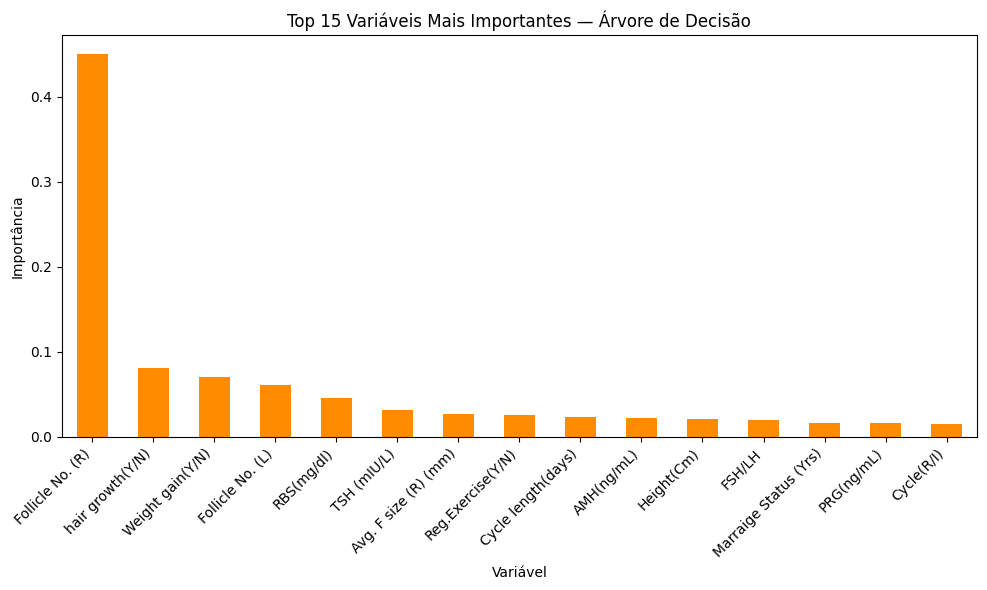

In [129]:
# Feature Importance — Árvore de Decisão (para comparação)

importancias_arvore = pd.Series(
    modelo_arvore.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

# Mostrando as 15 mais importantes
plt.figure(figsize=(10, 6))
importancias_arvore.head(15).plot(kind='bar', color='darkorange')
plt.title('Top 15 Variáveis Mais Importantes — Árvore de Decisão')
plt.ylabel('Importância')
plt.xlabel('Variável')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

c:\Users\sabri\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


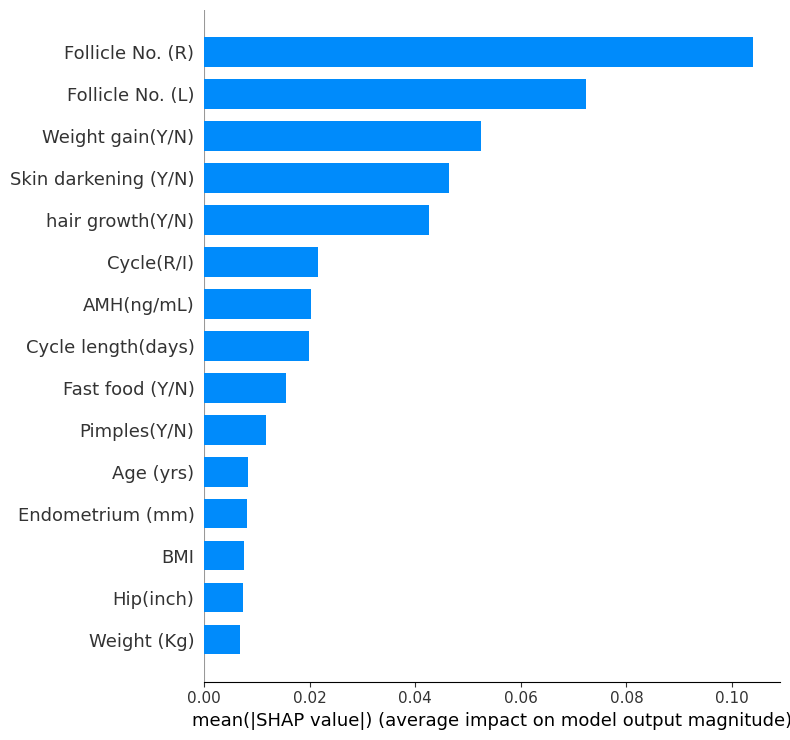

In [130]:
# Etapa 11 — SHAP Values
import shap

# Criando o explicador SHAP para o Random Forest
explicador = shap.TreeExplainer(modelo_rf)

# Calculando os SHAP values para o conjunto de teste
shap_values = explicador.shap_values(X_test)

# Gráfico de resumo — importância global
shap.summary_plot(shap_values[:, :, 1], X_test, 
                  plot_type="bar",
                  max_display=15)

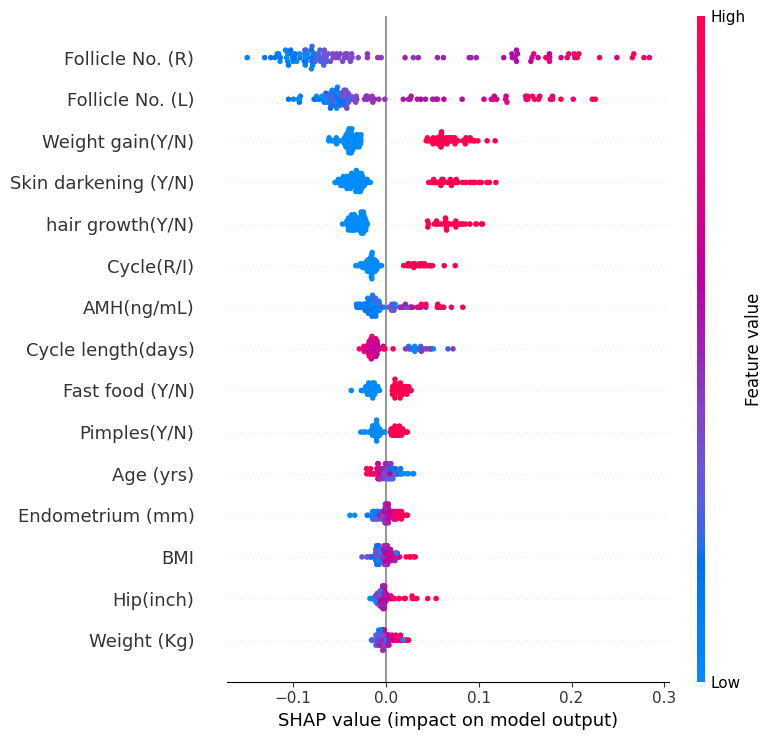

In [131]:
# SHAP Beeswarm Plot — mostra o efeito de cada variável
shap.summary_plot(shap_values[:, :, 1], X_test, max_display=15)